# ELS 3-Star 구조 설명 & 몬테카를로 100,000회 가격산출

worst-of **3기초자산 스텝다운 오토콜 ELS** 한 종목을 골라 계약 구조를 자세히 설명하고,
**3자산 상관(Cholesky) + Nelson–Siegel 곡선 기간구조 할인**으로 MC **100,000 경로** 이론가를 산출한다.

> 데이터셋 전체 `mc` 컬럼은 같은 방식(경로 10,000)으로 계산된다. 이 노트북은 한 상품을 100,000 경로로 정밀 재현.

In [1]:
import json, numpy as np, pandas as pd
from pathlib import Path
from datetime import date
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
D = ROOT / "data"; CA = D / "cache"
mapping = json.loads((CA / "udly_ticker_map.json").read_text(encoding="utf-8"))
def safe(t): return "px_" + t.replace("^","_").replace(".","_") + ".parquet"

# per-티커 로그수익률 + 252일 변동성
RET, VOL = {}, {}
for uid, t in mapping.items():
    if not t: continue
    f = CA / safe(t)
    if t in VOL or not f.exists(): continue
    s = pd.read_parquet(f)["close"].dropna(); s = s[~s.index.duplicated()]
    r = np.log(s).diff(); RET[t] = r
    VOL[t] = (r.rolling(252, min_periods=60).std()*np.sqrt(252)).dropna()

# Nelson-Siegel 곡선
CMT = {"DGS3MO":.25,"DGS6MO":.5,"DGS1":1.,"DGS2":2.,"DGS3":3.,"DGS5":5.,"DGS7":7.,"DGS10":10.}
CMTdf = pd.DataFrame({s: pd.read_parquet(CA/f"fred_{s}.parquet").iloc[:,0] for s in CMT}).sort_index().ffill()
taus = np.array(list(CMT.values())); LAM = 1.5
def nsb(t):
    x=t/LAM; e=np.exp(-x); return np.stack([np.ones_like(t),(1-e)/x,(1-e)/x-e],1)
def curve_beta(dt):
    row=CMTdf.asof(dt); beta,*_=np.linalg.lstsq(nsb(taus),row.values.astype(float),rcond=None); return beta
def zero_curve(beta,times): return (nsb(np.maximum(times,1e-6))@beta)/100.0

# raw: item별 3기초자산·행사가 스케줄
RAW = D/"raw"
ud = pd.read_csv(RAW/"LAKE_V2_DART_UDLY_INFO.csv", low_memory=False)
sc = pd.read_csv(RAW/"LAKE_V2_DART_SCHD_INFO.csv", low_memory=False)
u3map = ud.groupby("ITEM_CD")["UDLY_ID"].apply(list)
udly_nm = ud.groupby("ITEM_CD").apply(lambda g: dict(zip(g.UDLY_ID, g.UDLY_NM)))
sc1 = sc[sc.SCHD_TYPE==1].sort_values(["ITEM_CD","SEQ"])
strk_by = sc1.groupby("ITEM_CD")["STRK_1"].apply(lambda s:[float(x)/100 for x in s])
print("loaded caches | tickers", len(VOL))

C:\Users\Juhwankim\AppData\Local\Temp\ipykernel_23296\2355682073.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  udly_nm = ud.groupby("ITEM_CD").apply(lambda g: dict(zip(g.UDLY_ID, g.UDLY_NM)))


loaded caches | tickers 46


## 1. 대표 상품 선택
만기 3년·반기 관측(6회)·3기초자산 종가 확보 상품 중 하나를 고정 선택한다.

In [2]:
df = pd.read_parquet(CA/"els3_dataset.parquet")
def ok(it):
    ts=[mapping.get(x) for x in u3map.get(it,[])]
    return len([t for t in ts if t and t in VOL])==3 and isinstance(strk_by.get(it),list) and len(strk_by.get(it))>=2
cand = df[(df.tenor.between(2.9,3.05)) & (df.nobs==6)].copy()
cand = cand[cand["item"].map(ok)].sort_values("isu_ord")
row = cand.iloc[len(cand)//2]           # 중앙 시점의 대표 상품(결정적 선택)
it = row["item"]; ISU = date.fromordinal(int(row.isu_ord))
tickers=[mapping[x] for x in u3map[it]]; names=udly_nm[it]
strikes = strk_by[it]; B=float(row.B); c=float(row.coupon); ten=float(row.tenor)
print("ITEM_CD :", it, "| 발행일", ISU, "| 발행사", row.issuer if 'issuer' in row else '-')
print("기초자산 3 :", [(x, names[x], mapping[x]) for x in u3map[it]])
print(f"만기 {ten:.2f}년 | 관측 {int(row.nobs)}회 | 쿠폰(연) {c*100:.2f}% | KI 배리어 {B:.2f}")
print("행사가 스케줄(스텝다운):", [round(s,3) for s in strikes])

ITEM_CD : KR65333CG9B8 | 발행일 2019-11-13 | 발행사 104856
기초자산 3 : [('EU0009658145', 'EURO STOXX 50 지수', '^STOXX50E'), ('HK0000004330', 'HSCEI 지수', '^HSCE'), ('US78378X1072', 'S&P 500 지수', '^GSPC')]
만기 3.00년 | 관측 6회 | 쿠폰(연) 6.00% | KI 배리어 0.50
행사가 스케줄(스텝다운): [0.95, 0.9, 0.85, 0.85, 0.8, 0.8]


## 2. 상품 구조 상세

**worst-of 3기초자산 스텝다운 오토콜 ELS** — 세 기초자산 중 **가장 부진한(worst)** 종목 성과로 정산.

- **조기상환(오토콜)**: 반기마다(6·12·18·…개월) 관측. worst 성과가 그 회차 **행사가 이상**이면 즉시 **(원금 + 누적쿠폰)** 상환하고 종료.
- **스텝다운**: 행사가 스케줄이 회차마다 **낮아져**(예: 0.90→0.85→…) 뒤로 갈수록 조기상환이 쉬워진다.
- **낙인(Knock-In) 배리어 B**: 관측기간 중 worst가 한 번이라도 **B 미만**으로 떨어지면 KI 발생.
- **만기 정산** (조기상환 안 된 경우):
  1. worst ≥ 만기 행사가 → **원금 + 쿠폰**
  2. KI 미발생 → **원금 보장(1.0)**
  3. KI 발생 & worst < 만기행사가 → **worst 수준으로 손실**(원금손실)

정규화: 각 기초자산 발행시점 가격을 1로 두어 성과 = S/S₀. worst-of = 세 성과의 최소값.

### 스텝다운 조기상환 구조도
계단식으로 낮아지는 회차별 행사가(파랑), 낙인 배리어(빨강), 회차별 누적 쿠폰(초록)을 한눈에.

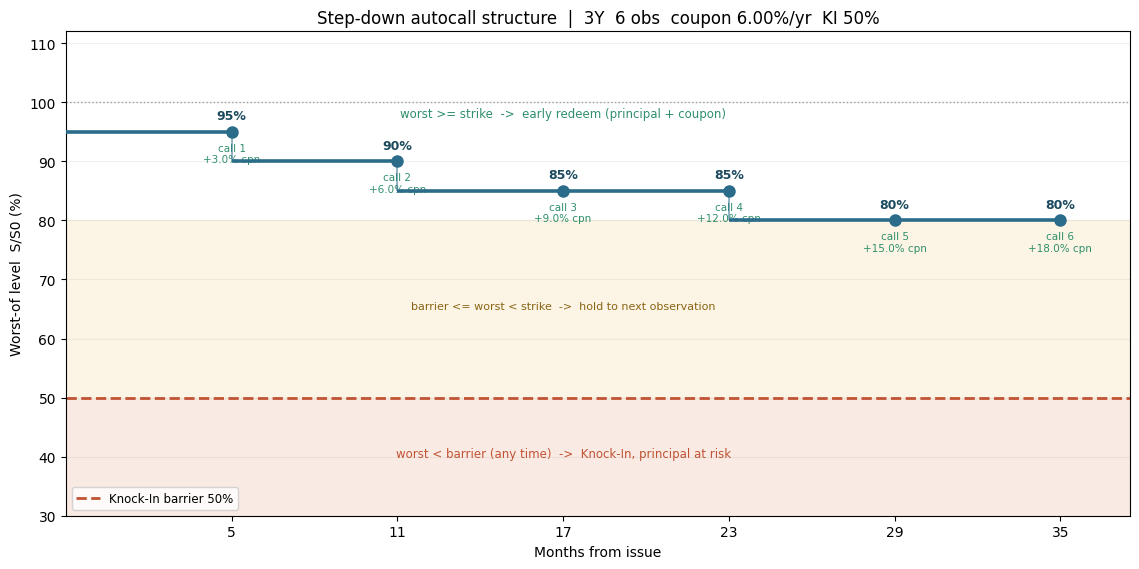

행사가 스케줄: ['95%', '90%', '85%', '85%', '80%', '80%'] | KI 50% | 만기까지 최대 누적쿠폰 18.0%


In [3]:
# 스텝다운 오토콜 구조도
nobs = len(strikes)
months = np.arange(1, nobs+1) * (ten/nobs) * 12
fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.axhspan(30, B*100, color="#f7d9cf", alpha=.55, zorder=0)               # KI/loss zone
ax.axhspan(B*100, strikes[-1]*100, color="#fbf1dc", alpha=.7, zorder=0)   # hold zone (approx)
ax.axhline(100, color="#999", ls=":", lw=1, zorder=1)                     # initial 100%
prev = 0
for i,(m,s) in enumerate(zip(months, strikes)):
    ax.hlines(s*100, prev, m, color="#2b6c8a", lw=2.6, zorder=3)          # 계단 행사가
    if i>0: ax.vlines(prev, strikes[i-1]*100, s*100, color="#2b6c8a", lw=1.2, ls="-", alpha=.6, zorder=3)
    ax.plot(m, s*100, "o", color="#2b6c8a", ms=8, zorder=4)
    ax.annotate(f"{s*100:.0f}%", (m, s*100), textcoords="offset points", xytext=(0,9), ha="center",
                fontsize=9, color="#1c4a5f", fontweight="bold")
    ax.annotate(f"call {i+1}\n+{c*months[i]/12*100:.1f}% cpn", (m, s*100), textcoords="offset points",
                xytext=(0,-22), ha="center", fontsize=7.5, color="#2f8f6b")
    prev = m
ax.axhline(B*100, color="#c15334", ls="--", lw=2, zorder=2, label=f"Knock-In barrier {B*100:.0f}%")
ax.set_xlim(0, months[-1]*1.07); ax.set_ylim(30, 112)
ax.set_xlabel("Months from issue"); ax.set_ylabel("Worst-of level  S/S0 (%)")
ax.set_title(f"Step-down autocall structure  |  {ten:.0f}Y  {nobs} obs  coupon {c*100:.2f}%/yr  KI {B*100:.0f}%")
ax.set_xticks(months); ax.set_xticklabels([f"{int(m)}" for m in months])
ax.text(months[-1]*0.5, (100+strikes[0]*100)/2, "worst >= strike  ->  early redeem (principal + coupon)",
        ha="center", fontsize=8.5, color="#2f8f6b")
ax.text(months[-1]*0.5, (strikes[-1]*100+B*100)/2, "barrier <= worst < strike  ->  hold to next observation",
        ha="center", fontsize=8, color="#8a6414")
ax.text(months[-1]*0.5, (30+B*100)/2, "worst < barrier (any time)  ->  Knock-In, principal at risk",
        ha="center", fontsize=8.5, color="#c15334")
ax.legend(loc="lower left", fontsize=8.5); ax.grid(axis="y", alpha=.18)
fig.tight_layout(); plt.show()
print("행사가 스케줄:", [f"{s*100:.0f}%" for s in strikes], "| KI", f"{B*100:.0f}%",
      "| 만기까지 최대 누적쿠폰", f"{c*ten*100:.1f}%")

In [4]:
# 입력: per-자산 변동성 + 3x3 상관 (발행일 asof) + NS 곡선
dt = pd.Timestamp(ISU)
sigs = np.array([float(VOL[t].asof(dt)) for t in tickers])
def corr_asof(ts, dt, lam=0.97):
    cols=[RET[t][RET[t].index<dt].rename(t) for t in ts]
    x=pd.concat(cols,axis=1).dropna().values; Tn=len(x)
    w=lam**np.arange(Tn-1,-1,-1); w/=w.sum(); xm=(w[:,None]*x).sum(0); xc=x-xm
    cov=(w[:,None]*xc).T@xc; d=np.sqrt(np.diag(cov)); C=cov/np.outer(d,d)
    C=np.clip(C,-0.999,0.999); np.fill_diagonal(C,1.0); return C
corr = corr_asof(tickers, dt)
beta = curve_beta(dt)
print("자산별 연변동성:", dict(zip([names[x] for x in u3map[it]], sigs.round(3))))
print("상관행렬:\n", pd.DataFrame(corr, index=tickers, columns=tickers).round(3))
otimes = np.arange(1,int(row.nobs)+1)*(ten/int(row.nobs))
print("관측시점(년):", otimes.round(2))
print("NS 제로금리@관측:", (zero_curve(beta,otimes)*100).round(2), "%")

자산별 연변동성: {'EURO STOXX 50 지수': np.float64(0.139), 'HSCEI 지수': np.float64(0.163), 'S&P 500 지수': np.float64(0.154)}
상관행렬:
            ^STOXX50E  ^HSCE  ^GSPC
^STOXX50E      1.000  0.383  0.726
^HSCE          0.383  1.000  0.220
^GSPC          0.726  0.220  1.000
관측시점(년): [0.5 1.  1.5 2.  2.5 3. ]
NS 제로금리@관측: [1.58 1.58 1.59 1.6  1.62 1.65] %


## 3. 몬테카를로 100,000 경로 가격산출
3자산 상관 GBM(위험중립, forward 드리프트) + NS 기간구조 할인. 진단(회차별 조기상환·KI·손실 확률) 포함.

In [5]:
def mc_price_diag(sigs, corr, beta, B, strikes, c, ten, n=100000, seed=0):
    nobs=len(strikes); msub=max(1,int(round(ten*12/nobs))); nstep=nobs*msub
    dt=ten/nstep; times=np.arange(1,nstep+1)*dt
    z=zero_curve(beta,times); DF=np.exp(-z*times)
    lnDF=np.concatenate([[0.0],np.log(DF)]); fdt=-(lnDF[1:]-lnDF[:-1])
    L=np.linalg.cholesky(corr); sig=np.asarray(sigs)
    rng=np.random.default_rng(seed)
    Z=rng.standard_normal((n,nstep,3))@L.T
    incr=(fdt[None,:,None]-0.5*sig[None,None,:]**2*dt)+sig[None,None,:]*np.sqrt(dt)*Z
    S=np.exp(np.cumsum(incr,1)); worst=S.min(2)
    alive=np.ones(n,bool); pay=np.zeros(n); ki=np.zeros(n,bool)
    when=np.full(n,-1)  # 조기상환 회차 (-1=만기)
    for j in range(nobs):
        oi=(j+1)*msub-1
        ki=ki|(worst[:,:oi+1].min(1)<B)
        hit=alive&(worst[:,oi]>=strikes[j])
        pay[hit]=(1+c*times[oi])*DF[oi]; when[hit]=j; alive[hit]=False
    wT=worst[alive,-1]; kiA=ki[alive]
    pay[alive]=np.where(wT>=strikes[-1],1+c*ten,np.where(~kiA,1.0,wT))*DF[-1]
    # 진단
    redeem_prob=[(when==j).mean() for j in range(nobs)]
    mat_mask=(when==-1)
    mat_gain=(mat_mask & (worst[:,-1]>=strikes[-1])).mean()
    mat_par =(mat_mask & (worst[:,-1]<strikes[-1]) & (~ki)).mean()
    mat_loss=(mat_mask & (worst[:,-1]<strikes[-1]) & ( ki)).mean()
    return dict(fair=pay.mean(), pay=pay, when=when, ki_prob=ki.mean(),
                redeem_prob=redeem_prob, mat_gain=mat_gain, mat_par=mat_par, mat_loss=mat_loss,
                DF=DF, otimes=times[(np.arange(1,nobs+1)*msub-1)])

res = mc_price_diag(sigs, corr, beta, B, strikes, c, ten, n=100000)
print(f"■ MC 이론가(fair value) = {res['fair']:.4f}  (발행가 대비, 100,000 경로)")
print(f"■ 낙인(KI) 확률 = {res['ki_prob']*100:.1f}%")
for j,p in enumerate(res['redeem_prob']): print(f"   {j+1}회차 조기상환 확률: {p*100:5.1f}%")
print(f"■ 만기 원금+쿠폰 {res['mat_gain']*100:.1f}% | 만기 원금보장 {res['mat_par']*100:.1f}% | 만기 손실 {res['mat_loss']*100:.1f}%")
print(f"■ 실제 시장 발행 공정가(fair, 데이터셋) = {row.fair:.4f}  | 기존 단일자산 mc = {row.mc:.4f}")

■ MC 이론가(fair value) = 1.0217  (발행가 대비, 100,000 경로)
■ 낙인(KI) 확률 = 1.6%
   1회차 조기상환 확률:  44.9%
   2회차 조기상환 확률:  19.3%
   3회차 조기상환 확률:  10.9%
   4회차 조기상환 확률:   3.6%
   5회차 조기상환 확률:   4.5%
   6회차 조기상환 확률:   1.9%
■ 만기 원금+쿠폰 0.0% | 만기 원금보장 13.5% | 만기 손실 1.3%
■ 실제 시장 발행 공정가(fair, 데이터셋) = 0.9675  | 기존 단일자산 mc = 1.0210


## 4. 시각화 (payoff 분포 · 상환시점 분포)

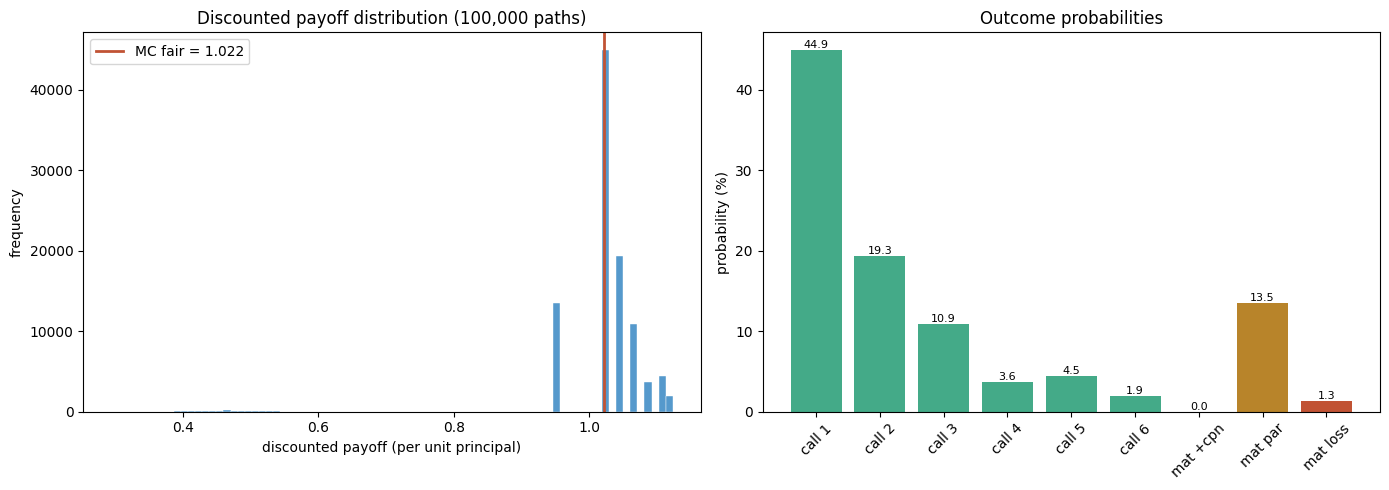

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].hist(res['pay'], bins=80, color="#59c", edgecolor="white", linewidth=.3)
ax[0].axvline(res['fair'], color="#c15334", lw=2, label=f"MC fair = {res['fair']:.3f}")
ax[0].set_title("Discounted payoff distribution (100,000 paths)")
ax[0].set_xlabel("discounted payoff (per unit principal)"); ax[0].set_ylabel("frequency"); ax[0].legend()

labels=[f"call {j+1}" for j in range(len(res['redeem_prob']))]+["mat +cpn","mat par","mat loss"]
vals=[p*100 for p in res['redeem_prob']]+[res['mat_gain']*100,res['mat_par']*100,res['mat_loss']*100]
colors=["#4a8"]*len(res['redeem_prob'])+["#59c","#b8842a","#c15334"]
ax[1].bar(labels, vals, color=colors)
ax[1].set_title("Outcome probabilities"); ax[1].set_ylabel("probability (%)")
ax[1].tick_params(axis="x", rotation=45)
for i,v in enumerate(vals): ax[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout(); plt.show()

## 5. 요약

- **구조**: worst-of 3자산, 반기 오토콜(스텝다운 행사가), KI 배리어, 만기 3분기 정산.
- **가격**: 3자산 상관을 Cholesky로 반영한 상관 GBM + NS 곡선 **기간구조 할인**으로 **100,000 경로** MC.
- 대부분 확률질량은 **초기 회차 조기상환**(쿠폰 수취)에 몰리고, 꼬리에 **KI 후 만기손실**이 위치 → 이 비대칭이 이론가를 1.0 아래로 끌어내린다.
- 데이터셋 전체는 동일 로직(경로 10,000)으로 `mc`를 만들어 PI/DeepONet의 **stage-1 앵커**로 사용한다.